In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray as rxr
import cartopy.crs as ccrs

In [ ]:
CanESM_hist_tas = xr.open_dataset("../../data/CanESM5_historical_tas.nc", engine="netcdf4")
CanESM_spp_tas = xr.open_dataset("../../data/CanESM5_ssp_tas.nc", engine="netcdf4")

In [ ]:
CanESM_1850_2100_tas = xr.concat([CanESM_hist_tas["tas"], CanESM_spp_tas["tas"]], dim="time")
CanESM_1850_2100_tas.to_netcdf("../../data/CanESM_1850-2100_tas.nc")

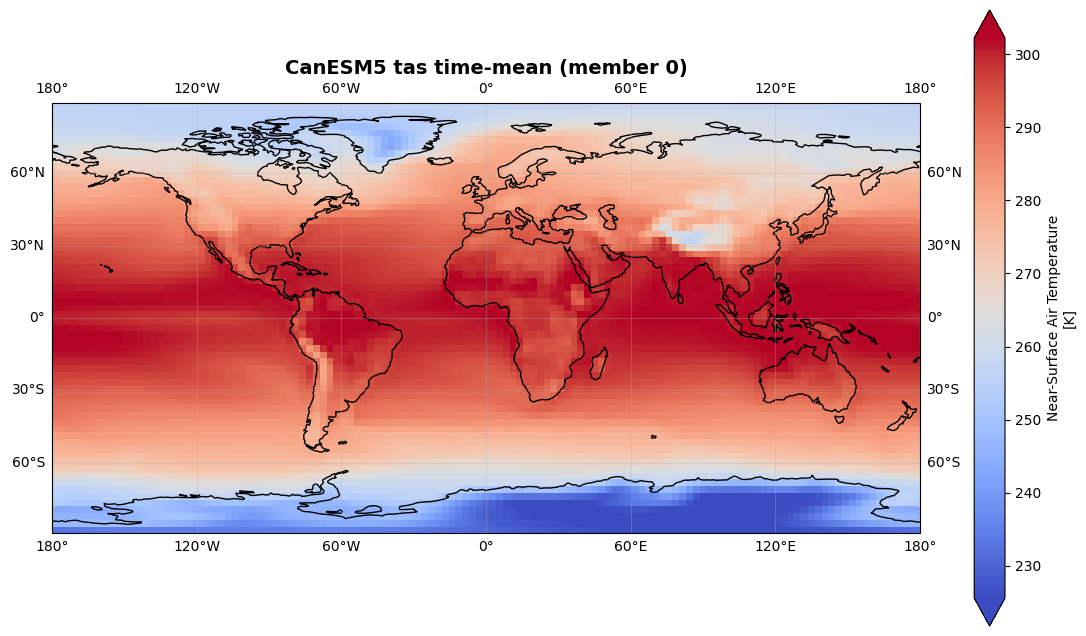

In [ ]:
# Testing Graph
CanESM_1850_2100_tas = xr.open_dataset("../../data/CanESM_1850-2100_tas.nc", engine="netcdf4")
map_da = CanESM_1850_2100_tas["tas"]
if "time" in map_da.dims:
    map_da = map_da.mean("time")
if "member" in map_da.dims:
    map_da = map_da.isel(member=0)

fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(linewidth=1)
ax.gridlines(draw_labels=True, alpha=0.3)

map_da.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="coolwarm", robust=True, x="lon", y="lat")
plt.title("CanESM5 tas time-mean 1850-2100 (member 0)", fontsize=14, fontweight="bold")
plt.show()